# Strategy Lab 02 - Oscillation / residual-reversion strategy

这篇只做震荡恢复。假设最近窗口里趋势不强，价格主要围绕 `trend + cycle` 波动。

策略逻辑：

1. 先用 `abs(trend_strength)` 判断是否是弱趋势/震荡环境。
2. `fair value = exp(trend + cycle)`。
3. `residual_z < -entry_z`：价格低于当前趋势+周期结构，做多或买入。
4. `residual_z > entry_z`：价格高于当前趋势+周期结构，卖出或做空。
5. 回到 `residual_z ≈ 0` 附近退出。
6. 信号在第 t 根 bar 结束后生成，回测用下一根 bar 的开盘价成交。

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display
from quant_trading.data import load_sample_goog_ohlcv
from quant_trading.decomposition_features import walkforward_price_volume_features
from quant_trading.strategy_lab import (
    TrendFollowingConfig,
    OscillationReversionConfig,
    backtest_signal_set,
    execution_price_panel,
    decomposition_trend_following_signals,
    decomposition_oscillation_reversion_signals,
    plot_signal_analysis,
    stats_table,
)
from quant_trading.strategy_baselines import (
    buy_and_hold_weights,
    dual_moving_average_weights,
    bollinger_mean_reversion_weights,
)
from quant_trading.strategy_lab import backtest_target_weights_next_bar

CHART_DIR = Path("examples/quant_trading/reports/strategy_lab/charts")

In [2]:
ohlcv = load_sample_goog_ohlcv(trim_start="2014-01-01")
symbol = "GOOG"
close = ohlcv["Close"].rename(symbol).to_frame()
volume = ohlcv["Volume"].rename(symbol).to_frame()
execution_prices = execution_price_panel(ohlcv, field="Open", next_bar=True)
execution_prices.columns = [symbol]

features = walkforward_price_volume_features(
    close, volume, method="STL", period=42, train_window=180, step=21, z_window=63
)

In [3]:
signal = decomposition_oscillation_reversion_signals(
    close,
    features,
    config=OscillationReversionConfig(
        entry_residual_z=1.75,
        exit_residual_z=0.15,
        max_abs_trend_strength=0.35,
        require_cycle_turn=True,
        allow_short=True,
    ),
    name="detime_STL_oscillation_reversion",
)

bt = backtest_signal_set(
    close, signal, execution_prices=execution_prices, fee_bps=5, slippage_bps=2, periods_per_year=252
)

baselines = {
    "buy_hold": buy_and_hold_weights(close),
    "classic_bollinger_20_2": bollinger_mean_reversion_weights(close, window=20, entry_z=2.0, allow_short=True),
}
results = {signal.name: bt}
for name, weights in baselines.items():
    results[name] = backtest_target_weights_next_bar(
        close, weights, execution_prices=execution_prices, fee_bps=5, slippage_bps=2, periods_per_year=252, name=name
    )

stats_table(results)

,strategy,total_return,cagr,sharpe,max_drawdown,calmar,volatility,hit_rate,trade_win_rate,average_trade_directional_return,orders,round_trips,median_bars_held,average_turnover,average_gross_exposure,fee_bps,slippage_bps,periods_per_year,execution_model
1,buy_hold,0.887479,0.172116,0.799165,-0.192787,0.892778,0.232171,0.524802,NaN,NaN,1.0,0.0,NaN,0.000000,1.000000,5.0,2.0,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy
2,classic_bollinger_20_2,0.323543,0.072592,0.478267,-0.207060,0.350584,0.181238,0.255952,0.725,0.009610,79.0,40.0,9.5,0.080357,0.490079,5.0,2.0,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy
0,detime_STL_oscillation_reversion,0.063435,0.015495,0.372000,-0.065752,0.235656,0.043914,0.068452,1.000,0.070517,9.0,3.0,42.0,0.004347,0.069338,5.0,2.0,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy


In [4]:
# residual_z is the actual traded deviation.  Negative values mean price is below trend+cycle.
pd.concat({
    "close": close[symbol],
    "fair_value": signal.diagnostics["fair_value"][symbol],
    "residual_z": signal.diagnostics["residual_z"][symbol],
    "weak_trend_regime": signal.diagnostics["weak_trend_regime"][symbol],
    "target_weight": signal.target_weights[symbol],
}, axis=1).tail(12)

,close,fair_value,residual_z,weak_trend_regime,target_weight
Date,,,,,
2017-12-14,1049.150024,1029.967131,0.725678,1.0,0.0
2017-12-15,1064.189941,1029.967131,0.725678,1.0,0.0
2017-12-18,1077.140015,1078.319116,-0.118095,1.0,0.0
2017-12-19,1070.680054,1078.319116,-0.118095,1.0,0.0
2017-12-20,1064.949951,1078.319116,-0.118095,1.0,0.0
2017-12-21,1063.630005,1078.319116,-0.118095,1.0,0.0
2017-12-22,1060.119995,1078.319116,-0.118095,1.0,0.0
2017-12-26,1056.739990,1078.319116,-0.118095,1.0,0.0
2017-12-27,1049.369995,1078.319116,-0.118095,1.0,0.0


In [5]:
bt.orders.tail(12)

,asset,signal_date,fill_date,action,previous_weight,new_weight,delta_weight,fill_price
0,GOOG,2015-02-19,2015-02-20,sell_or_short,0.000000,-0.802886,-0.802886,541.642944
1,GOOG,2015-03-20,2015-03-23,buy,-0.802886,-0.462620,0.340267,558.895569
2,GOOG,2015-04-21,2015-04-22,cover,-0.462620,0.000000,0.462620,532.936829
3,GOOG,2015-09-18,2015-09-21,buy,0.000000,0.700360,0.700360,634.400024
4,GOOG,2015-10-19,2015-10-20,sell_or_short,0.700360,0.291135,-0.409225,664.039978
5,GOOG,2015-11-17,2015-11-18,sell,0.291135,0.000000,-0.291135,727.580017
6,GOOG,2016-03-21,2016-03-22,sell_or_short,0.000000,-0.687773,-0.687773,737.460022
7,GOOG,2016-04-20,2016-04-21,buy,-0.687773,-0.383438,0.304335,755.380005
8,GOOG,2016-05-19,2016-05-20,cover,-0.383438,0.000000,0.383438,701.619995


In [6]:
bt.trades.tail(12)

,asset,side,entry_signal_date,entry_fill_date,exit_signal_date,exit_fill_date,entry_price,exit_price,bars_held,entry_weight,directional_return,approx_weighted_return_after_cost
0,GOOG,short,2015-02-19,2015-02-20,2015-04-21,2015-04-22,541.642944,532.936829,42,-0.802886,0.016074,0.012343
1,GOOG,long,2015-09-18,2015-09-21,2015-11-17,2015-11-18,634.400024,727.580017,42,0.700360,0.146879,0.102378
2,GOOG,short,2016-03-21,2016-03-22,2016-05-19,2016-05-20,737.460022,701.619995,42,-0.687773,0.048599,0.032944


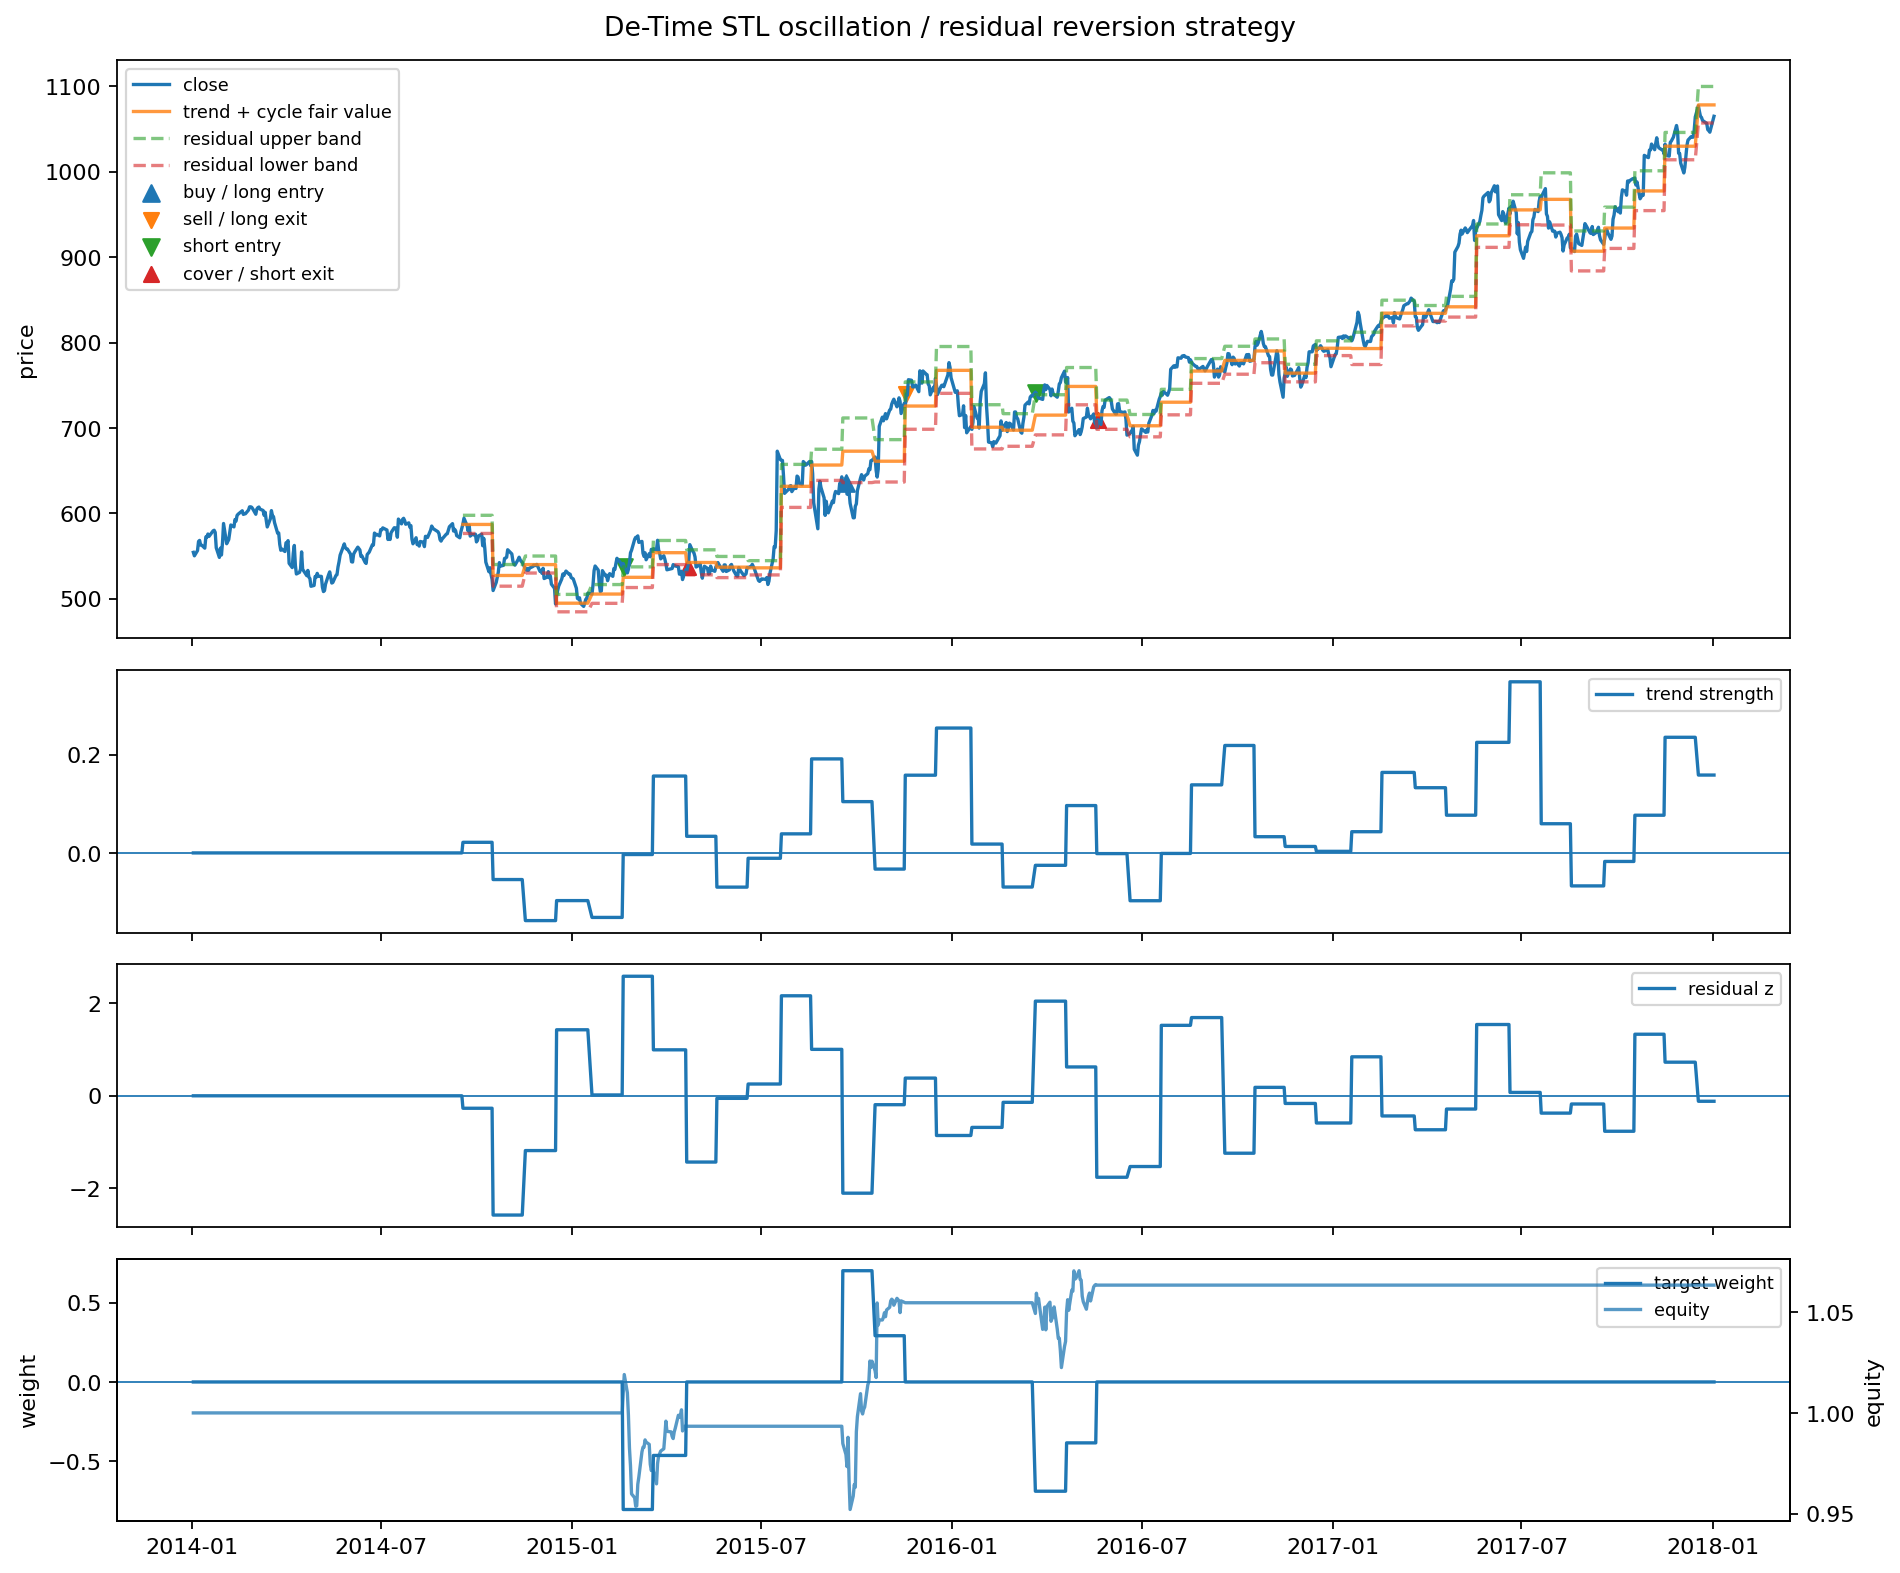

'examples/quant_trading/reports/strategy_lab/charts/notebook_02_oscillation_reversion.png'

In [7]:
out = CHART_DIR / "notebook_02_oscillation_reversion.png"
plot_signal_analysis(ohlcv, signal, bt, asset=symbol, output_path=out, title="De-Time STL oscillation / residual reversion strategy")
display(Image(filename=str(out)))
out.as_posix()